## 0. Setup

In [ ]:

!pip install -q torchinfo scikit-learn --upgrade


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 28.3 MB/s eta 0:00:00


In [ ]:

import os, time, copy, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split

import torchvision
from torchvision import transforms, models
from torchvision.datasets import OxfordIIITPet

from sklearn.model_selection import KFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ---- Global knobs (tune these if you want longer/shorter runs) ----
IMG_SIZE       = 224
NUM_CLASSES    = 37
EPOCHS_QUICK   = 5      # epochs used for every comparison experiment (Sections 5-9)
EPOCHS_TL      = 8      # epochs for transfer learning (Section 10)
EPOCHS_FINAL   = 12     # epochs for the final retrained model (Section 12)
BATCH_SIZE     = 32


Using device: cuda


## 1. Dataset and Experimental Setup
Downloads the Oxford-IIIT Pet dataset (auto-downloaded by `torchvision`), resizes all images to
224×224×3, normalizes them using ImageNet statistics (required for MobileNetV2), and creates
**train / validation / test** splits. The test split is kept completely untouched until Section 12.


In [ ]:

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# torchvision ships an official trainval/test split for this dataset
full_trainval_raw = OxfordIIITPet(root="./data", split="trainval", target_types="category",
                                   download=True, transform=train_tfms)
full_trainval_eval = OxfordIIITPet(root="./data", split="trainval", target_types="category",
                                    download=True, transform=eval_tfms)
test_set = OxfordIIITPet(root="./data", split="test", target_types="category",
                          download=True, transform=eval_tfms)

CLASS_NAMES = full_trainval_raw.classes
print("Number of classes:", len(CLASS_NAMES))
print("Trainval size:", len(full_trainval_raw), " Test size:", len(test_set))

# Split trainval -> train (80%) / val (20%), fixed indices so every experiment is comparable
n_total = len(full_trainval_raw)
n_val = int(0.2 * n_total)
n_train = n_total - n_val
generator = torch.Generator().manual_seed(SEED)
train_idx, val_idx = random_split(range(n_total), [n_train, n_val], generator=generator)
train_idx, val_idx = list(train_idx), list(val_idx)

train_set = Subset(full_trainval_raw, train_idx)   # augmented transforms
val_set   = Subset(full_trainval_eval, val_idx)    # plain eval transforms (no augmentation)

print(f"Train: {len(train_set)}  Val: {len(val_set)}  Test: {len(test_set)}")

def make_loader(dataset, batch_size=BATCH_SIZE, shuffle=False, workers=2):
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle,
                       num_workers=workers, pin_memory=True)

train_loader = make_loader(train_set, shuffle=True)
val_loader   = make_loader(val_set)
test_loader  = make_loader(test_set)


100%|██████████| 792M/792M [00:30<00:00, 26.2MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.7MB/s]


Number of classes: 37
Trainval size: 3680  Test size: 3669
Train: 2944  Val: 736  Test: 3669


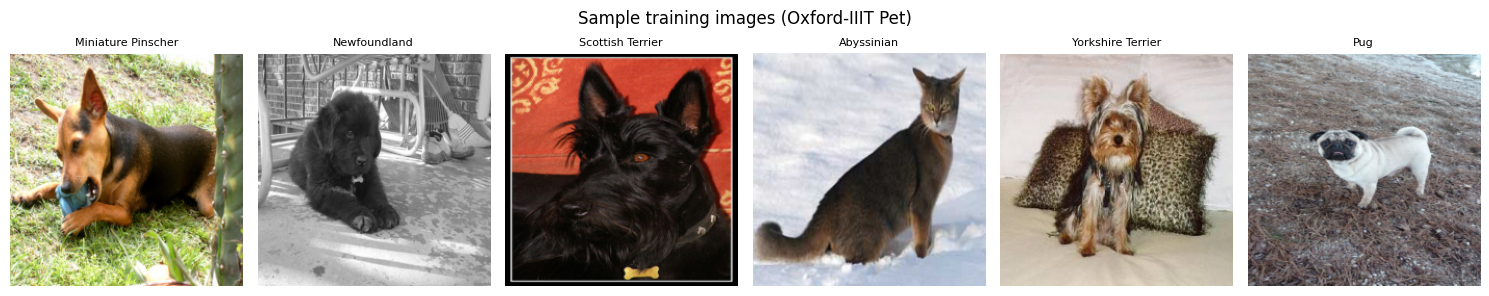

In [ ]:

# Quick visual sanity check of a batch
def denorm(img_t):
    img = img_t.clone().permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(img, 0, 1)

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(denorm(imgs[i]))
    ax.set_title(CLASS_NAMES[labels[i]], fontsize=8)
    ax.axis("off")
plt.suptitle("Sample training images (Oxford-IIIT Pet)")
plt.tight_layout()
plt.show()


## 2. Core Model Builder and Training Utilities
`build_scratch_mobilenetv2` builds MobileNetV2 **with random (untrained) weights** — this is the
version used for Sections 5–9, since studying the *effect* of initialization/regularization/optimizers
is only meaningful when the network isn't already pretrained.
`build_pretrained_mobilenetv2` builds the **ImageNet-pretrained** version used for transfer learning
in Section 10 (and for the final model in Section 12).


In [ ]:

def build_scratch_mobilenetv2(num_classes=NUM_CLASSES, dropout=0.2, remove_batchnorm=False):
    model = models.mobilenet_v2(weights=None, dropout=dropout)
    model.classifier[1] = nn.Linear(model.last_channel, num_classes)
    if remove_batchnorm:
        # Replace every BatchNorm2d with Identity to study BN's effect (Section 7)
        for name, module in model.named_modules():
            if isinstance(module, nn.BatchNorm2d):
                parent = model
                parts = name.split(".")
                for p in parts[:-1]:
                    parent = getattr(parent, p) if not p.isdigit() else parent[int(p)]
                last = parts[-1]
                if last.isdigit():
                    parent[int(last)] = nn.Identity()
                else:
                    setattr(parent, last, nn.Identity())
    return model.to(DEVICE)


def build_pretrained_mobilenetv2(num_classes=NUM_CLASSES, freeze_base=True, dropout=0.2):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
    model.classifier[1] = nn.Linear(model.last_channel, num_classes)
    if freeze_base:
        for name, param in model.named_parameters():
            if "classifier" not in name:
                param.requires_grad = False
    else:
        # Fine-tuning: unfreeze only the later feature blocks, keep early layers frozen
        for name, param in model.named_parameters():
            param.requires_grad = False
        for name, param in model.features[-4:].named_parameters():
            param.requires_grad = True
        for param in model.classifier.parameters():
            param.requires_grad = True
    return model.to(DEVICE)


In [ ]:

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, 100.0 * correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    return running_loss / total, 100.0 * correct / total, all_preds, all_labels

def run_training(model, train_loader, val_loader, optimizer, epochs, criterion=None, tag=""):
    criterion = criterion or nn.CrossEntropyLoss()
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    start = time.time()
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc, _, _ = evaluate(model, val_loader, criterion)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        print(f"[{tag}] Epoch {epoch}/{epochs} | "
              f"train_loss={tr_loss:.4f} train_acc={tr_acc:.2f}% | "
              f"val_loss={va_loss:.4f} val_acc={va_acc:.2f}%")
    elapsed = time.time() - start
    return history, elapsed

def plot_curves(histories_dict, key, ylabel, title):
    plt.figure(figsize=(7, 5))
    for label, hist in histories_dict.items():
        plt.plot(range(1, len(hist[key]) + 1), hist[key], marker="o", label=label)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


## 3. Weight Initialization (Section 5)
Compares **Zero**, **Random (Normal)**, **Xavier/Glorot**, and **He** initialization on the same
from-scratch MobileNetV2, all trained for `EPOCHS_QUICK` epochs under identical settings
(Adam, lr=1e-3, batch size 32).


In [ ]:

def apply_init(model, method):
    def init_fn(m):
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            if method == "zero":
                nn.init.zeros_(m.weight)
            elif method == "random":
                nn.init.normal_(m.weight, mean=0.0, std=0.05)
            elif method == "xavier":
                nn.init.xavier_uniform_(m.weight)
            elif method == "he":
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            if getattr(m, "bias", None) is not None:
                nn.init.zeros_(m.bias)
    model.apply(init_fn)
    return model

init_methods = ["zero", "random", "xavier", "he"]
init_histories = {}

for method in init_methods:
    torch.manual_seed(SEED)
    model = build_scratch_mobilenetv2()
    model = apply_init(model, method)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    hist, elapsed = run_training(model, train_loader, val_loader, optimizer,
                                  EPOCHS_QUICK, tag=f"init={method}")
    init_histories[method] = hist
    del model
    torch.cuda.empty_cache()


[init=zero] Epoch 1/5 | train_loss=3.6114 train_acc=2.17% | val_loss=3.6117 val_acc=2.17%
[init=zero] Epoch 2/5 | train_loss=3.6111 train_acc=2.14% | val_loss=3.6123 val_acc=1.77%
[init=zero] Epoch 3/5 | train_loss=3.6109 train_acc=2.96% | val_loss=3.6128 val_acc=1.77%
[init=zero] Epoch 4/5 | train_loss=3.6108 train_acc=2.31% | val_loss=3.6134 val_acc=1.77%
[init=zero] Epoch 5/5 | train_loss=3.6107 train_acc=2.96% | val_loss=3.6139 val_acc=1.77%
[init=random] Epoch 1/5 | train_loss=3.7859 train_acc=4.93% | val_loss=4.1769 val_acc=4.89%
[init=random] Epoch 2/5 | train_loss=3.5812 train_acc=7.07% | val_loss=3.4898 val_acc=8.42%
[init=random] Epoch 3/5 | train_loss=3.3783 train_acc=10.22% | val_loss=3.4474 val_acc=8.56%
[init=random] Epoch 4/5 | train_loss=3.1634 train_acc=12.87% | val_loss=3.4215 val_acc=13.86%
[init=random] Epoch 5/5 | train_loss=3.0005 train_acc=17.19% | val_loss=3.3247 val_acc=11.28%
[init=xavier] Epoch 1/5 | train_loss=3.7539 train_acc=5.10% | val_loss=3.9939 val_acc

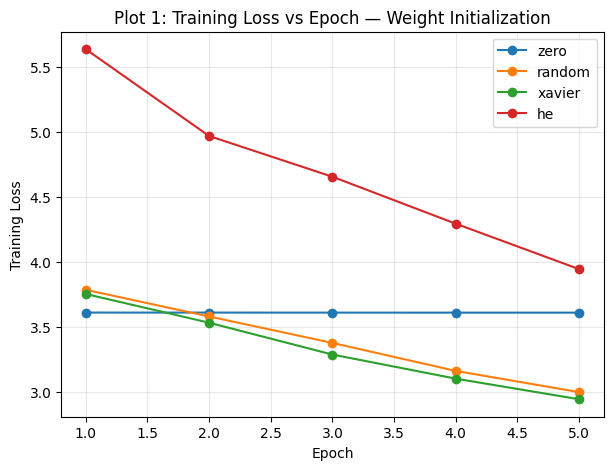

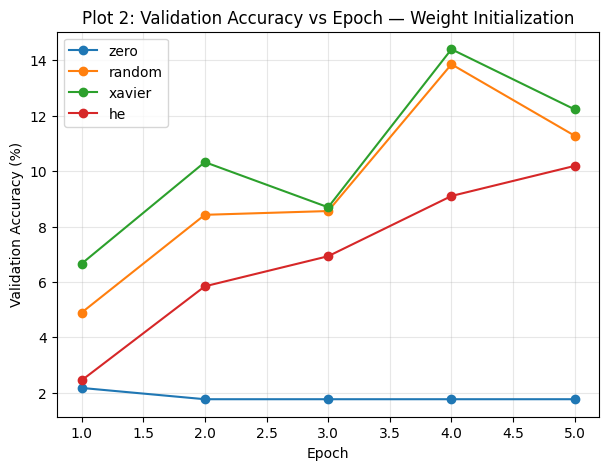

Best-performing initialization on validation accuracy: xavier


In [ ]:

# Plot 1: Training Loss vs Epoch (per initialization method)
plot_curves(init_histories, "train_loss", "Training Loss",
            "Plot 1: Training Loss vs Epoch — Weight Initialization")

# Plot 2: Validation Accuracy vs Epoch (per initialization method)
plot_curves(init_histories, "val_acc", "Validation Accuracy (%)",
            "Plot 2: Validation Accuracy vs Epoch — Weight Initialization")

best_init = max(init_histories, key=lambda k: init_histories[k]["val_acc"][-1])
print("Best-performing initialization on validation accuracy:", best_init)


## 4. Regularization and Overfitting (Section 6)
Compares **No regularization**, **L2 regularization** (`weight_decay` in the optimizer),
**Dropout**, and **Batch Normalization** (MobileNetV2's default BN vs. disabled BN),
all built with `best_init` from Section 3.


In [ ]:

reg_configs = {
    "No Regularization": dict(weight_decay=0.0, dropout=0.0, remove_bn=False),
    "L2 Regularization": dict(weight_decay=1e-4, dropout=0.0, remove_bn=False),
    "Dropout":            dict(weight_decay=0.0, dropout=0.5, remove_bn=False),
    "Batch Normalization": dict(weight_decay=0.0, dropout=0.0, remove_bn=False),  # BN is default/on
}

reg_histories = {}
for name, cfg in reg_configs.items():
    torch.manual_seed(SEED)
    model = build_scratch_mobilenetv2(dropout=cfg["dropout"], remove_batchnorm=cfg["remove_bn"])
    model = apply_init(model, best_init)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=cfg["weight_decay"])
    hist, elapsed = run_training(model, train_loader, val_loader, optimizer,
                                  EPOCHS_QUICK, tag=name)
    reg_histories[name] = hist
    del model
    torch.cuda.empty_cache()


[No Regularization] Epoch 1/5 | train_loss=3.7190 train_acc=4.93% | val_loss=3.7514 val_acc=7.34%
[No Regularization] Epoch 2/5 | train_loss=3.4918 train_acc=7.64% | val_loss=3.6363 val_acc=9.51%
[No Regularization] Epoch 3/5 | train_loss=3.3008 train_acc=11.48% | val_loss=3.5462 val_acc=8.83%
[No Regularization] Epoch 4/5 | train_loss=3.1135 train_acc=13.11% | val_loss=3.4788 val_acc=10.60%
[No Regularization] Epoch 5/5 | train_loss=2.9824 train_acc=16.95% | val_loss=3.5437 val_acc=11.41%
[L2 Regularization] Epoch 1/5 | train_loss=3.7100 train_acc=5.30% | val_loss=3.6898 val_acc=5.84%
[L2 Regularization] Epoch 2/5 | train_loss=3.4607 train_acc=7.91% | val_loss=3.7060 val_acc=9.78%
[L2 Regularization] Epoch 3/5 | train_loss=3.2814 train_acc=11.68% | val_loss=3.4093 val_acc=9.51%
[L2 Regularization] Epoch 4/5 | train_loss=3.0940 train_acc=14.95% | val_loss=3.2661 val_acc=14.95%
[L2 Regularization] Epoch 5/5 | train_loss=2.9488 train_acc=18.27% | val_loss=3.2560 val_acc=12.64%
[Dropout] 

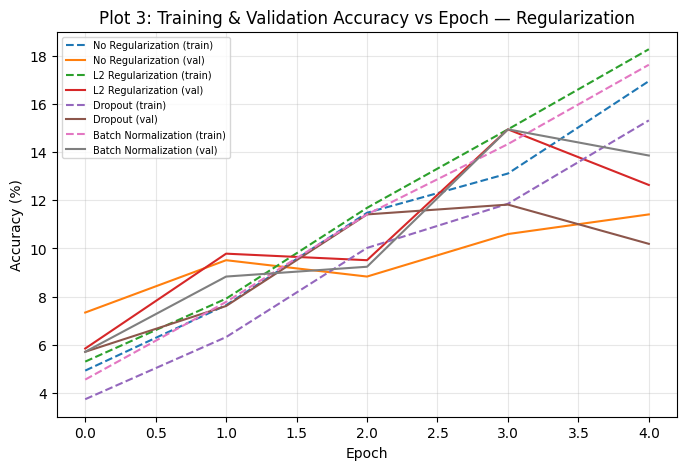

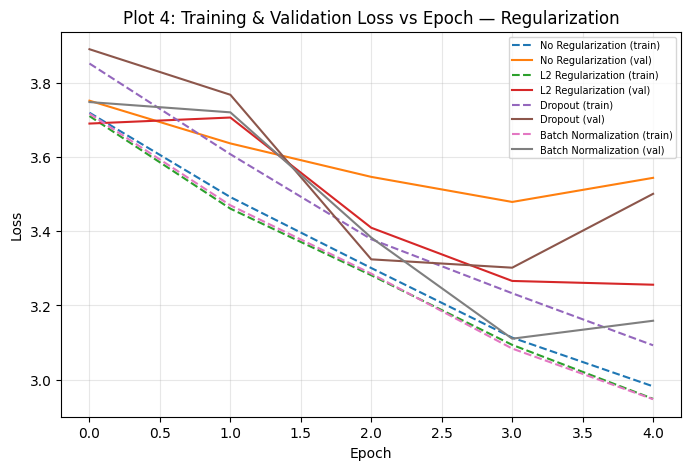

,Config,Final Train Acc (%),Final Val Acc (%),Generalization Gap (%)
0,No Regularization,16.95,11.41,5.54
1,L2 Regularization,18.27,12.64,5.64
2,Dropout,15.32,10.19,5.13
3,Batch Normalization,17.63,13.86,3.77


In [ ]:

# Plot 3: Training and Validation Accuracy vs Epoch (all 4 configs)
plt.figure(figsize=(8, 5))
for name, hist in reg_histories.items():
    plt.plot(hist["train_acc"], linestyle="--", label=f"{name} (train)")
    plt.plot(hist["val_acc"], linestyle="-", label=f"{name} (val)")
plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)")
plt.title("Plot 3: Training & Validation Accuracy vs Epoch — Regularization")
plt.legend(fontsize=7); plt.grid(alpha=0.3); plt.show()

# Plot 4: Training and Validation Loss vs Epoch (all 4 configs)
plt.figure(figsize=(8, 5))
for name, hist in reg_histories.items():
    plt.plot(hist["train_loss"], linestyle="--", label=f"{name} (train)")
    plt.plot(hist["val_loss"], linestyle="-", label=f"{name} (val)")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Plot 4: Training & Validation Loss vs Epoch — Regularization")
plt.legend(fontsize=7); plt.grid(alpha=0.3); plt.show()

# Generalization gap table
gap_rows = []
for name, hist in reg_histories.items():
    gap_rows.append({
        "Config": name,
        "Final Train Acc (%)": round(hist["train_acc"][-1], 2),
        "Final Val Acc (%)": round(hist["val_acc"][-1], 2),
        "Generalization Gap (%)": round(hist["train_acc"][-1] - hist["val_acc"][-1], 2),
    })
pd.DataFrame(gap_rows)


## 5. Batch Normalization — Numerical Example (Section 7)

For a mini-batch $x = [2, 4, 6, 8]$:

$$\mu_B = \frac{2+4+6+8}{4} = 5$$

$$\sigma_B^2 = \frac{(2-5)^2+(4-5)^2+(6-5)^2+(8-5)^2}{4} = 5, \quad \sqrt{5}\approx 2.236$$

$$\hat{x} \approx [-1.342,\ -0.447,\ 0.447,\ 1.342]$$

With $\gamma=1,\ \beta=0$, these normalized values are the final outputs. The cell below
reproduces this computation, then trains **with vs without Batch Normalization** for Plot 5.


In [ ]:

x = np.array([2, 4, 6, 8], dtype=float)
mu = x.mean()
var = x.var()
x_hat = (x - mu) / np.sqrt(var + 1e-8)
gamma, beta = 1.0, 0.0
y = gamma * x_hat + beta
print("mu =", mu, " var =", var, " std =", np.sqrt(var))
print("x_hat =", np.round(x_hat, 3))
print("y (gamma=1, beta=0) =", np.round(y, 3))


mu = 5.0  var = 5.0  std = 2.23606797749979
x_hat = [-1.342 -0.447  0.447  1.342]
y (gamma=1, beta=0) = [-1.342 -0.447  0.447  1.342]


[With BN] Epoch 1/5 | train_loss=3.7411 train_acc=5.06% | val_loss=3.7502 val_acc=5.71%
[With BN] Epoch 2/5 | train_loss=3.5022 train_acc=7.34% | val_loss=3.7878 val_acc=5.71%
[With BN] Epoch 3/5 | train_loss=3.2944 train_acc=10.84% | val_loss=3.3870 val_acc=9.10%
[With BN] Epoch 4/5 | train_loss=3.1283 train_acc=13.86% | val_loss=3.2875 val_acc=12.09%
[With BN] Epoch 5/5 | train_loss=3.0222 train_acc=16.68% | val_loss=3.2416 val_acc=14.81%
[Without BN] Epoch 1/5 | train_loss=3.6114 train_acc=2.17% | val_loss=3.6117 val_acc=2.17%
[Without BN] Epoch 2/5 | train_loss=3.6111 train_acc=2.14% | val_loss=3.6123 val_acc=1.77%
[Without BN] Epoch 3/5 | train_loss=3.6109 train_acc=2.96% | val_loss=3.6128 val_acc=1.77%
[Without BN] Epoch 4/5 | train_loss=3.6108 train_acc=2.31% | val_loss=3.6134 val_acc=1.77%
[Without BN] Epoch 5/5 | train_loss=3.6107 train_acc=2.96% | val_loss=3.6139 val_acc=1.77%


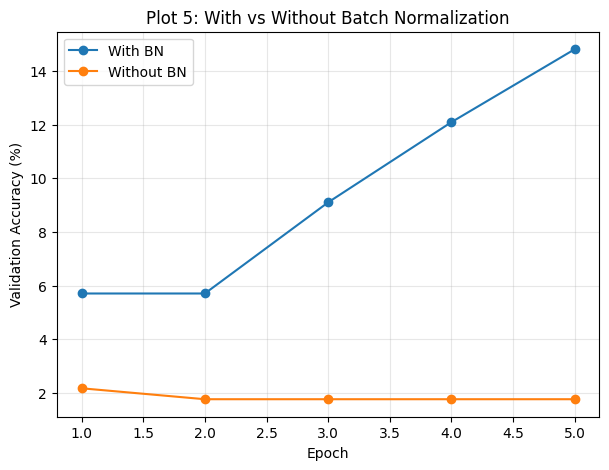

In [ ]:

bn_configs = {"With BN": False, "Without BN": True}
bn_histories = {}
for name, remove_bn in bn_configs.items():
    torch.manual_seed(SEED)
    model = build_scratch_mobilenetv2(remove_batchnorm=remove_bn)
    model = apply_init(model, best_init)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    hist, elapsed = run_training(model, train_loader, val_loader, optimizer,
                                  EPOCHS_QUICK, tag=name)
    bn_histories[name] = hist
    del model
    torch.cuda.empty_cache()

# Plot 5: With vs Without Batch Normalization
plot_curves(bn_histories, "val_acc", "Validation Accuracy (%)",
            "Plot 5: With vs Without Batch Normalization")


## 6. Optimization Algorithms (Section 8)
Compares **SGD**, **Momentum** (SGD + momentum=0.9), **RMSProp**, and **Adam** — same
architecture/init, `EPOCHS_QUICK` epochs, lr=1e-3 for all (SGD often needs a higher lr; this is
noted in the discussion).


In [ ]:

def make_optimizer(name, params, lr=1e-3):
    if name == "SGD":
        return optim.SGD(params, lr=lr)
    elif name == "Momentum":
        return optim.SGD(params, lr=lr, momentum=0.9)
    elif name == "RMSProp":
        return optim.RMSprop(params, lr=lr)
    elif name == "Adam":
        return optim.Adam(params, lr=lr)
    raise ValueError(name)

optimizer_names = ["SGD", "Momentum", "RMSProp", "Adam"]
opt_histories = {}
opt_times = {}

for name in optimizer_names:
    torch.manual_seed(SEED)
    model = build_scratch_mobilenetv2()
    model = apply_init(model, best_init)
    optimizer = make_optimizer(name, model.parameters(), lr=1e-3)
    hist, elapsed = run_training(model, train_loader, val_loader, optimizer,
                                  EPOCHS_QUICK, tag=name)
    opt_histories[name] = hist
    opt_times[name] = elapsed
    del model
    torch.cuda.empty_cache()


[SGD] Epoch 1/5 | train_loss=3.7257 train_acc=2.48% | val_loss=3.6544 val_acc=2.31%
[SGD] Epoch 2/5 | train_loss=3.6740 train_acc=2.85% | val_loss=3.6276 val_acc=3.12%
[SGD] Epoch 3/5 | train_loss=3.6416 train_acc=2.75% | val_loss=3.6074 val_acc=4.62%
[SGD] Epoch 4/5 | train_loss=3.6222 train_acc=3.43% | val_loss=3.6069 val_acc=2.72%
[SGD] Epoch 5/5 | train_loss=3.6131 train_acc=3.40% | val_loss=3.6087 val_acc=3.12%
[Momentum] Epoch 1/5 | train_loss=3.6820 train_acc=2.85% | val_loss=3.7017 val_acc=2.72%
[Momentum] Epoch 2/5 | train_loss=3.6352 train_acc=3.29% | val_loss=3.6901 val_acc=4.48%
[Momentum] Epoch 3/5 | train_loss=3.5651 train_acc=5.60% | val_loss=4.1193 val_acc=4.76%
[Momentum] Epoch 4/5 | train_loss=3.5162 train_acc=5.57% | val_loss=3.4850 val_acc=7.88%
[Momentum] Epoch 5/5 | train_loss=3.4559 train_acc=7.74% | val_loss=3.4136 val_acc=8.70%
[RMSProp] Epoch 1/5 | train_loss=3.8175 train_acc=4.93% | val_loss=3.5669 val_acc=6.39%
[RMSProp] Epoch 2/5 | train_loss=3.4175 train_a

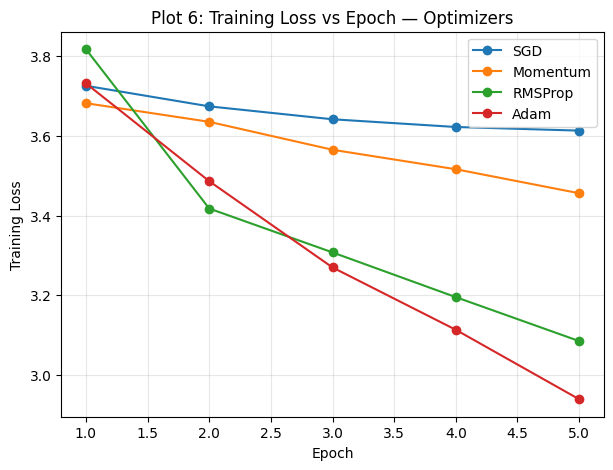

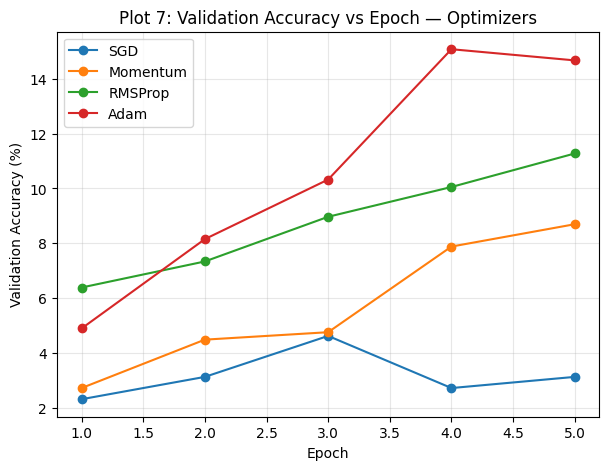

,Optimizer,Final Loss,Best Val. Accuracy (%),Epoch to Converge,Time (s)
0,SGD,3.6131,4.62,3,100.3
1,Momentum,3.4559,8.70,5,103.3
2,RMSProp,3.0848,11.28,5,98.5
3,Adam,2.9388,15.08,4,99.8


In [ ]:

# Plot 6: Training Loss vs Epoch (optimizers)
plot_curves(opt_histories, "train_loss", "Training Loss",
            "Plot 6: Training Loss vs Epoch — Optimizers")

# Plot 7: Validation Accuracy vs Epoch (optimizers)
plot_curves(opt_histories, "val_acc", "Validation Accuracy (%)",
            "Plot 7: Validation Accuracy vs Epoch — Optimizers")

def epoch_to_converge(hist, tol=0.5):
    # first epoch at which val_acc is within `tol`% of its own best value
    best = max(hist["val_acc"])
    for i, acc in enumerate(hist["val_acc"], start=1):
        if acc >= best - tol:
            return i
    return len(hist["val_acc"])

opt_table = []
for name in optimizer_names:
    hist = opt_histories[name]
    opt_table.append({
        "Optimizer": name,
        "Final Loss": round(hist["train_loss"][-1], 4),
        "Best Val. Accuracy (%)": round(max(hist["val_acc"]), 2),
        "Epoch to Converge": epoch_to_converge(hist),
        "Time (s)": round(opt_times[name], 1),
    })
opt_df = pd.DataFrame(opt_table)
opt_df


## 7. CNN Hyperparameter Tuning (Section 9)
Following the **one-hyperparameter-at-a-time** rule: sweeps Learning Rate, Batch Size, and Dropout
Rate independently, keeping everything else fixed at a sensible default
(optimizer=Adam, lr=1e-3, batch=32, dropout=0.2), using the best initializer found earlier.


In [ ]:

def train_quick_config(lr=1e-3, batch_size=BATCH_SIZE, dropout=0.2, epochs=EPOCHS_QUICK, tag=""):
    torch.manual_seed(SEED)
    model = build_scratch_mobilenetv2(dropout=dropout)
    model = apply_init(model, best_init)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    tr_loader = make_loader(train_set, batch_size=batch_size, shuffle=True)
    va_loader = make_loader(val_set, batch_size=batch_size)
    hist, elapsed = run_training(model, tr_loader, va_loader, optimizer, epochs, tag=tag)
    del model
    torch.cuda.empty_cache()
    return hist

# ---- Learning Rate sweep ----
lr_values = [0.001, 0.0001]
lr_results = {}
for lr in lr_values:
    hist = train_quick_config(lr=lr, tag=f"lr={lr}")
    lr_results[lr] = max(hist["val_acc"])

# ---- Batch Size sweep ----
batch_values = [16, 32, 64]
batch_results = {}
for bs in batch_values:
    hist = train_quick_config(batch_size=bs, tag=f"batch={bs}")
    batch_results[bs] = max(hist["val_acc"])

# ---- Dropout Rate sweep ----
dropout_values = [0.0, 0.25, 0.5]
dropout_results = {}
for dr in dropout_values:
    hist = train_quick_config(dropout=dr, tag=f"dropout={dr}")
    dropout_results[dr] = max(hist["val_acc"])


[lr=0.001] Epoch 1/5 | train_loss=3.7507 train_acc=4.93% | val_loss=4.1507 val_acc=4.89%
[lr=0.001] Epoch 2/5 | train_loss=3.5471 train_acc=6.59% | val_loss=3.5073 val_acc=10.05%
[lr=0.001] Epoch 3/5 | train_loss=3.3348 train_acc=11.85% | val_loss=3.3172 val_acc=9.78%
[lr=0.001] Epoch 4/5 | train_loss=3.1363 train_acc=13.45% | val_loss=3.3301 val_acc=14.13%
[lr=0.001] Epoch 5/5 | train_loss=3.0004 train_acc=16.98% | val_loss=3.3074 val_acc=13.04%
[lr=0.0001] Epoch 1/5 | train_loss=3.6385 train_acc=3.26% | val_loss=3.6119 val_acc=3.26%
[lr=0.0001] Epoch 2/5 | train_loss=3.5705 train_acc=4.72% | val_loss=3.5453 val_acc=3.53%
[lr=0.0001] Epoch 3/5 | train_loss=3.5140 train_acc=6.56% | val_loss=3.4827 val_acc=5.57%
[lr=0.0001] Epoch 4/5 | train_loss=3.4396 train_acc=7.40% | val_loss=3.4710 val_acc=8.29%
[lr=0.0001] Epoch 5/5 | train_loss=3.3618 train_acc=9.54% | val_loss=3.4256 val_acc=6.39%
[batch=16] Epoch 1/5 | train_loss=3.7805 train_acc=5.33% | val_loss=3.6771 val_acc=7.07%
[batch=16]

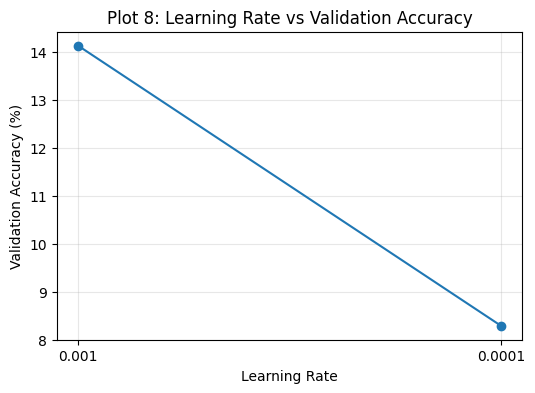

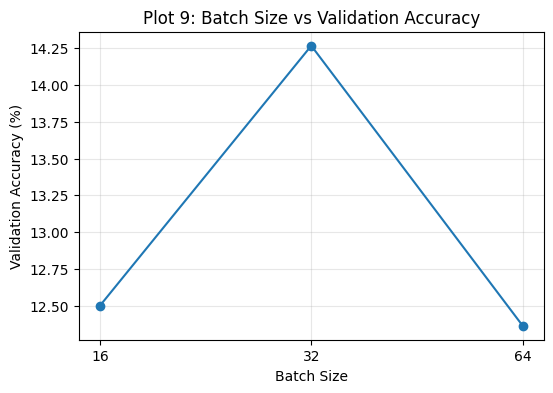

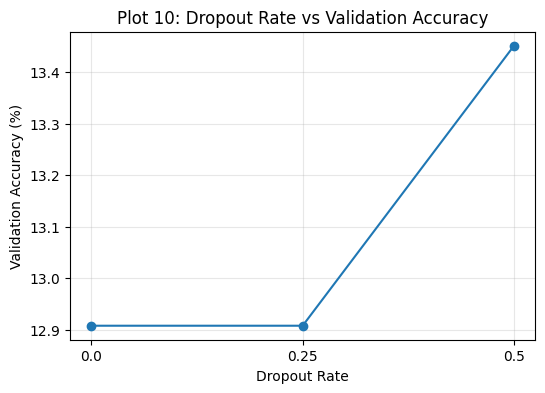

LR results: {0.001: 14.130434782608695, 0.0001: 8.28804347826087}
Batch size results: {16: 12.5, 32: 14.266304347826088, 64: 12.36413043478261}
Dropout results: {0.0: 12.907608695652174, 0.25: 12.907608695652174, 0.5: 13.451086956521738}
Best LR=0.001, Best batch size=32, Best dropout=0.5


In [ ]:

# Plot 8: Learning Rate vs Validation Accuracy
plt.figure(figsize=(6, 4))
plt.plot(list(map(str, lr_results.keys())), list(lr_results.values()), marker="o")
plt.xlabel("Learning Rate"); plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 8: Learning Rate vs Validation Accuracy")
plt.grid(alpha=0.3); plt.show()

# Plot 9: Batch Size vs Validation Accuracy
plt.figure(figsize=(6, 4))
plt.plot(list(map(str, batch_results.keys())), list(batch_results.values()), marker="o")
plt.xlabel("Batch Size"); plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 9: Batch Size vs Validation Accuracy")
plt.grid(alpha=0.3); plt.show()

# Plot 10: Dropout Rate vs Validation Accuracy
plt.figure(figsize=(6, 4))
plt.plot(list(map(str, dropout_results.keys())), list(dropout_results.values()), marker="o")
plt.xlabel("Dropout Rate"); plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 10: Dropout Rate vs Validation Accuracy")
plt.grid(alpha=0.3); plt.show()

print("LR results:", lr_results)
print("Batch size results:", batch_results)
print("Dropout results:", dropout_results)

best_lr = max(lr_results, key=lr_results.get)
best_batch = max(batch_results, key=batch_results.get)
best_dropout = max(dropout_results, key=dropout_results.get)
print(f"Best LR={best_lr}, Best batch size={best_batch}, Best dropout={best_dropout}")


## 8. Transfer Learning and Fine-Tuning (Section 10)
Uses **ImageNet-pretrained** MobileNetV2.
- **Case A — Feature Extraction:** freeze the pretrained backbone, train only the new classifier.
- **Case B — Fine-Tuning:** unfreeze the last few feature blocks, train with a smaller learning rate.


In [ ]:

torch.manual_seed(SEED)
model_fe = build_pretrained_mobilenetv2(freeze_base=True)
optimizer_fe = optim.Adam(filter(lambda p: p.requires_grad, model_fe.parameters()), lr=1e-3)
hist_fe, time_fe = run_training(model_fe, train_loader, val_loader, optimizer_fe,
                                 EPOCHS_TL, tag="Feature Extraction")

torch.manual_seed(SEED)
model_ft = build_pretrained_mobilenetv2(freeze_base=False)
optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model_ft.parameters()), lr=1e-4)
hist_ft, time_ft = run_training(model_ft, train_loader, val_loader, optimizer_ft,
                                 EPOCHS_TL, tag="Fine-Tuning")

tl_histories = {"Feature Extraction": hist_fe, "Fine-Tuning": hist_ft}


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 108MB/s] 


[Feature Extraction] Epoch 1/8 | train_loss=1.7485 train_acc=59.75% | val_loss=0.7715 val_acc=84.24%
[Feature Extraction] Epoch 2/8 | train_loss=0.6274 train_acc=85.94% | val_loss=0.5232 val_acc=87.36%
[Feature Extraction] Epoch 3/8 | train_loss=0.4451 train_acc=89.20% | val_loss=0.4544 val_acc=86.96%
[Feature Extraction] Epoch 4/8 | train_loss=0.3520 train_acc=91.27% | val_loss=0.4357 val_acc=86.96%
[Feature Extraction] Epoch 5/8 | train_loss=0.2892 train_acc=93.14% | val_loss=0.4055 val_acc=88.72%
[Feature Extraction] Epoch 6/8 | train_loss=0.2575 train_acc=93.78% | val_loss=0.3957 val_acc=87.23%
[Feature Extraction] Epoch 7/8 | train_loss=0.2177 train_acc=95.55% | val_loss=0.3797 val_acc=86.96%
[Feature Extraction] Epoch 8/8 | train_loss=0.1974 train_acc=94.90% | val_loss=0.3617 val_acc=88.59%
[Fine-Tuning] Epoch 1/8 | train_loss=2.2188 train_acc=53.57% | val_loss=1.1307 val_acc=82.20%
[Fine-Tuning] Epoch 2/8 | train_loss=0.8696 train_acc=84.75% | val_loss=0.6460 val_acc=86.96%
[Fin

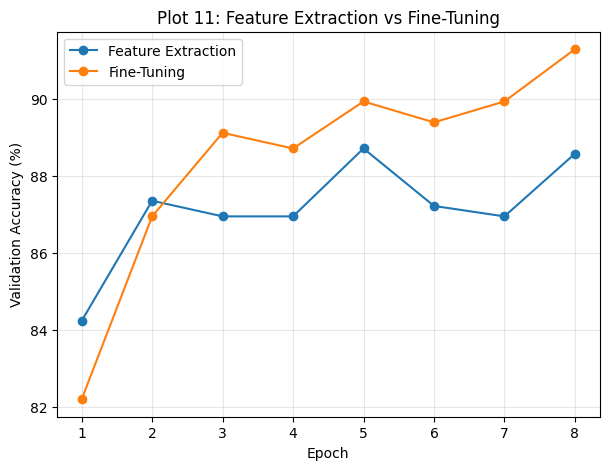

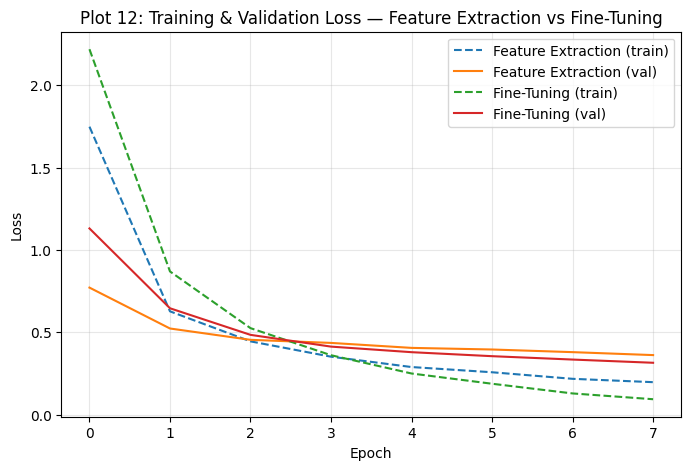

Feature Extraction best val acc: 88.72%  (140.2s)
Fine-Tuning best val acc:        91.30%  (141.7s)


In [ ]:

# Plot 11: Feature Extraction vs Fine-Tuning (Validation Accuracy)
plot_curves(tl_histories, "val_acc", "Validation Accuracy (%)",
            "Plot 11: Feature Extraction vs Fine-Tuning")

# Plot 12: Training and Validation Loss, before vs after fine-tuning
plt.figure(figsize=(8, 5))
for name, hist in tl_histories.items():
    plt.plot(hist["train_loss"], linestyle="--", label=f"{name} (train)")
    plt.plot(hist["val_loss"], linestyle="-", label=f"{name} (val)")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Plot 12: Training & Validation Loss — Feature Extraction vs Fine-Tuning")
plt.legend(); plt.grid(alpha=0.3); plt.show()

print(f"Feature Extraction best val acc: {max(hist_fe['val_acc']):.2f}%  ({time_fe:.1f}s)")
print(f"Fine-Tuning best val acc:        {max(hist_ft['val_acc']):.2f}%  ({time_ft:.1f}s)")


**Discussion — why does fine-tuning use a smaller learning rate?**
The pretrained layers already encode useful, well-tuned ImageNet features. A large learning rate
would apply large gradient updates that quickly *destroy* these features ("catastrophic
forgetting") before the new classifier has even stabilized. A small learning rate nudges the
pretrained weights gently towards the new dataset while preserving the general-purpose features
learned from ImageNet — unlike a newly-initialized classifier, which has no useful weights to
protect and therefore benefits from larger updates early in training.


## 9. K-Fold Cross-Validation (Section 11)
Selects 4 promising configurations from the experiments above and evaluates each with
**5-fold cross-validation** on the training data (test set stays untouched).


In [ ]:

# Combine train+val indices back into one pool for k-fold splitting (test set is NEVER touched here)
cv_pool_indices = train_idx + val_idx
cv_dataset_train_tfms = full_trainval_raw   # augmented
cv_dataset_eval_tfms  = full_trainval_eval  # plain

configs_to_cv = {
    "C1_BestInit_Adam":        dict(optimizer="Adam",     lr=1e-3, dropout=0.2, pretrained=False),
    "C2_BestInit_RMSProp":     dict(optimizer="RMSProp",  lr=1e-3, dropout=0.2, pretrained=False),
    "C3_BestHyperparams":      dict(optimizer="Adam",     lr=best_lr, dropout=best_dropout, pretrained=False),
    "C4_TransferLearning_FE":  dict(optimizer="Adam",     lr=1e-3, dropout=0.2, pretrained=True),
}

CV_EPOCHS = 4  # kept short since this runs 5x per configuration (20 short trainings total)

def build_model_for_config(cfg):
    if cfg["pretrained"]:
        return build_pretrained_mobilenetv2(freeze_base=True, dropout=cfg["dropout"])
    m = build_scratch_mobilenetv2(dropout=cfg["dropout"])
    return apply_init(m, best_init)

def run_kfold(cfg, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=SEED)
    fold_accs = []
    indices = np.array(cv_pool_indices)
    for fold, (tr_i, va_i) in enumerate(kf.split(indices), start=1):
        torch.manual_seed(SEED + fold)
        tr_subset = Subset(cv_dataset_train_tfms, indices[tr_i].tolist())
        va_subset = Subset(cv_dataset_eval_tfms, indices[va_i].tolist())
        tr_loader = make_loader(tr_subset, shuffle=True)
        va_loader = make_loader(va_subset)

        model = build_model_for_config(cfg)
        params = filter(lambda p: p.requires_grad, model.parameters())
        optimizer = make_optimizer(cfg["optimizer"], params, lr=cfg["lr"]) \
                    if cfg["optimizer"] in ("SGD", "Momentum", "RMSProp", "Adam") else optim.Adam(params, lr=cfg["lr"])
        hist, _ = run_training(model, tr_loader, va_loader, optimizer, CV_EPOCHS,
                                tag=f"fold{fold}")
        fold_accs.append(max(hist["val_acc"]))
        del model
        torch.cuda.empty_cache()
    return fold_accs

cv_results = {}
for name, cfg in configs_to_cv.items():
    print(f"\n=== Running 5-fold CV for {name} ===")
    fold_accs = run_kfold(cfg, k=5)
    cv_results[name] = fold_accs
    print(f"{name}: folds={np.round(fold_accs,2)}  mean={np.mean(fold_accs):.2f}  sd={np.std(fold_accs):.2f}")



=== Running 5-fold CV for C1_BestInit_Adam ===
[fold1] Epoch 1/4 | train_loss=3.7245 train_acc=5.20% | val_loss=3.9744 val_acc=4.76%
[fold1] Epoch 2/4 | train_loss=3.4897 train_acc=8.56% | val_loss=3.5058 val_acc=9.10%
[fold1] Epoch 3/4 | train_loss=3.2242 train_acc=11.75% | val_loss=3.4186 val_acc=10.33%
[fold1] Epoch 4/4 | train_loss=3.0718 train_acc=15.32% | val_loss=3.4223 val_acc=12.36%
[fold2] Epoch 1/4 | train_loss=3.7388 train_acc=4.72% | val_loss=4.0395 val_acc=5.84%
[fold2] Epoch 2/4 | train_loss=3.4570 train_acc=8.49% | val_loss=3.7044 val_acc=8.02%
[fold2] Epoch 3/4 | train_loss=3.2848 train_acc=11.65% | val_loss=3.4440 val_acc=9.38%
[fold2] Epoch 4/4 | train_loss=3.1379 train_acc=13.69% | val_loss=3.2492 val_acc=11.55%
[fold3] Epoch 1/4 | train_loss=3.7273 train_acc=4.45% | val_loss=3.6235 val_acc=6.52%
[fold3] Epoch 2/4 | train_loss=3.4747 train_acc=8.36% | val_loss=3.3743 val_acc=10.33%
[fold3] Epoch 3/4 | train_loss=3.3147 train_acc=11.31% | val_loss=3.6973 val_acc=8.9

In [ ]:

cv_table_rows = []
for name, accs in cv_results.items():
    row = {"Configuration": name}
    for i, a in enumerate(accs, start=1):
        row[f"F{i}"] = round(a, 2)
    row["Mean"] = round(np.mean(accs), 2)
    row["SD"] = round(np.std(accs), 2)
    cv_table_rows.append(row)
cv_df = pd.DataFrame(cv_table_rows)
cv_df


,Configuration,F1,F2,F3,F4,F5,Mean,SD
0,C1_BestInit_Adam,12.36,11.55,12.50,13.18,14.13,12.74,0.87
1,C2_BestInit_RMSProp,11.68,8.70,9.65,10.60,11.14,10.35,1.07
2,C3_BestHyperparams,11.28,12.09,12.50,11.41,12.36,11.93,0.50
3,C4_TransferLearning_FE,88.86,89.27,86.55,88.45,88.45,88.32,0.93


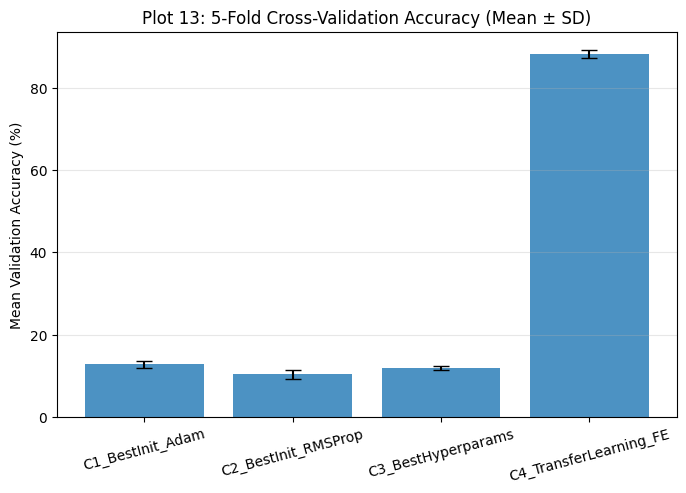

Best configuration by mean CV accuracy: C4_TransferLearning_FE


In [ ]:

# Plot 13: 5-Fold Cross-Validation Accuracy with error bars
names = list(cv_results.keys())
means = [np.mean(cv_results[n]) for n in names]
sds   = [np.std(cv_results[n]) for n in names]

plt.figure(figsize=(8, 5))
plt.bar(names, means, yerr=sds, capsize=6, alpha=0.8)
plt.ylabel("Mean Validation Accuracy (%)")
plt.title("Plot 13: 5-Fold Cross-Validation Accuracy (Mean ± SD)")
plt.xticks(rotation=15)
plt.grid(alpha=0.3, axis="y")
plt.show()

best_config_name = max(cv_results, key=lambda n: np.mean(cv_results[n]))
print("Best configuration by mean CV accuracy:", best_config_name)


## 10. Final Model Evaluation (Section 12)
Retrains the **best configuration selected by cross-validation** on the *complete* training data
(train+val), then evaluates it exactly once on the untouched **test set**.


In [ ]:

best_cfg = configs_to_cv[best_config_name]
print("Retraining final model with config:", best_config_name, best_cfg)

torch.manual_seed(SEED)
final_model = build_model_for_config(best_cfg)
final_train_loader = make_loader(Subset(cv_dataset_train_tfms, cv_pool_indices), shuffle=True)

params = filter(lambda p: p.requires_grad, final_model.parameters())
final_optimizer = make_optimizer(best_cfg["optimizer"], params, lr=best_cfg["lr"]) \
    if best_cfg["optimizer"] in ("SGD", "Momentum", "RMSProp", "Adam") else optim.Adam(params, lr=best_cfg["lr"])

start = time.time()
final_hist, final_train_time = run_training(final_model, final_train_loader, val_loader,
                                             final_optimizer, EPOCHS_FINAL, tag="FINAL")

criterion = nn.CrossEntropyLoss()
test_loss, test_acc, test_preds, test_labels = evaluate(final_model, test_loader, criterion)

precision = precision_score(test_labels, test_preds, average="macro", zero_division=0)
recall    = recall_score(test_labels, test_preds, average="macro", zero_division=0)
f1        = f1_score(test_labels, test_preds, average="macro", zero_division=0)
n_params  = sum(p.numel() for p in final_model.parameters())

print(f"\nTest Accuracy: {test_acc:.2f}%")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"F1-score (macro):  {f1:.4f}")
print(f"Training Time: {final_train_time:.1f}s")
print(f"Number of Parameters: {n_params:,}")


Retraining final model with config: C4_TransferLearning_FE {'optimizer': 'Adam', 'lr': 0.001, 'dropout': 0.2, 'pretrained': True}
[FINAL] Epoch 1/12 | train_loss=1.5611 train_acc=64.65% | val_loss=0.6062 val_acc=89.40%
[FINAL] Epoch 2/12 | train_loss=0.5624 train_acc=87.66% | val_loss=0.3638 val_acc=92.66%
[FINAL] Epoch 3/12 | train_loss=0.4082 train_acc=89.92% | val_loss=0.2980 val_acc=92.80%
[FINAL] Epoch 4/12 | train_loss=0.3224 train_acc=91.77% | val_loss=0.2334 val_acc=94.57%
[FINAL] Epoch 5/12 | train_loss=0.2925 train_acc=92.09% | val_loss=0.1905 val_acc=95.52%
[FINAL] Epoch 6/12 | train_loss=0.2403 train_acc=93.75% | val_loss=0.1603 val_acc=97.15%
[FINAL] Epoch 7/12 | train_loss=0.2135 train_acc=94.43% | val_loss=0.1426 val_acc=97.42%
[FINAL] Epoch 8/12 | train_loss=0.2000 train_acc=95.27% | val_loss=0.1127 val_acc=97.96%
[FINAL] Epoch 9/12 | train_loss=0.1697 train_acc=95.54% | val_loss=0.1079 val_acc=97.83%
[FINAL] Epoch 10/12 | train_loss=0.1639 train_acc=95.76% | val_loss=0

In [ ]:

final_report = pd.DataFrame([{
    "Mean CV Accuracy": round(np.mean(cv_results[best_config_name]), 2),
    "CV Standard Deviation": round(np.std(cv_results[best_config_name]), 2),
    "Test Accuracy": round(test_acc, 2),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1-score": round(f1, 4),
    "Training Time (s)": round(final_train_time, 1),
    "Number of Parameters": n_params,
}])
final_report


,Mean CV Accuracy,CV Standard Deviation,Test Accuracy,Precision,Recall,F1-score,Training Time (s),Number of Parameters
0,88.32,0.93,87.9,0.8829,0.8782,0.8779,251.6,2271269


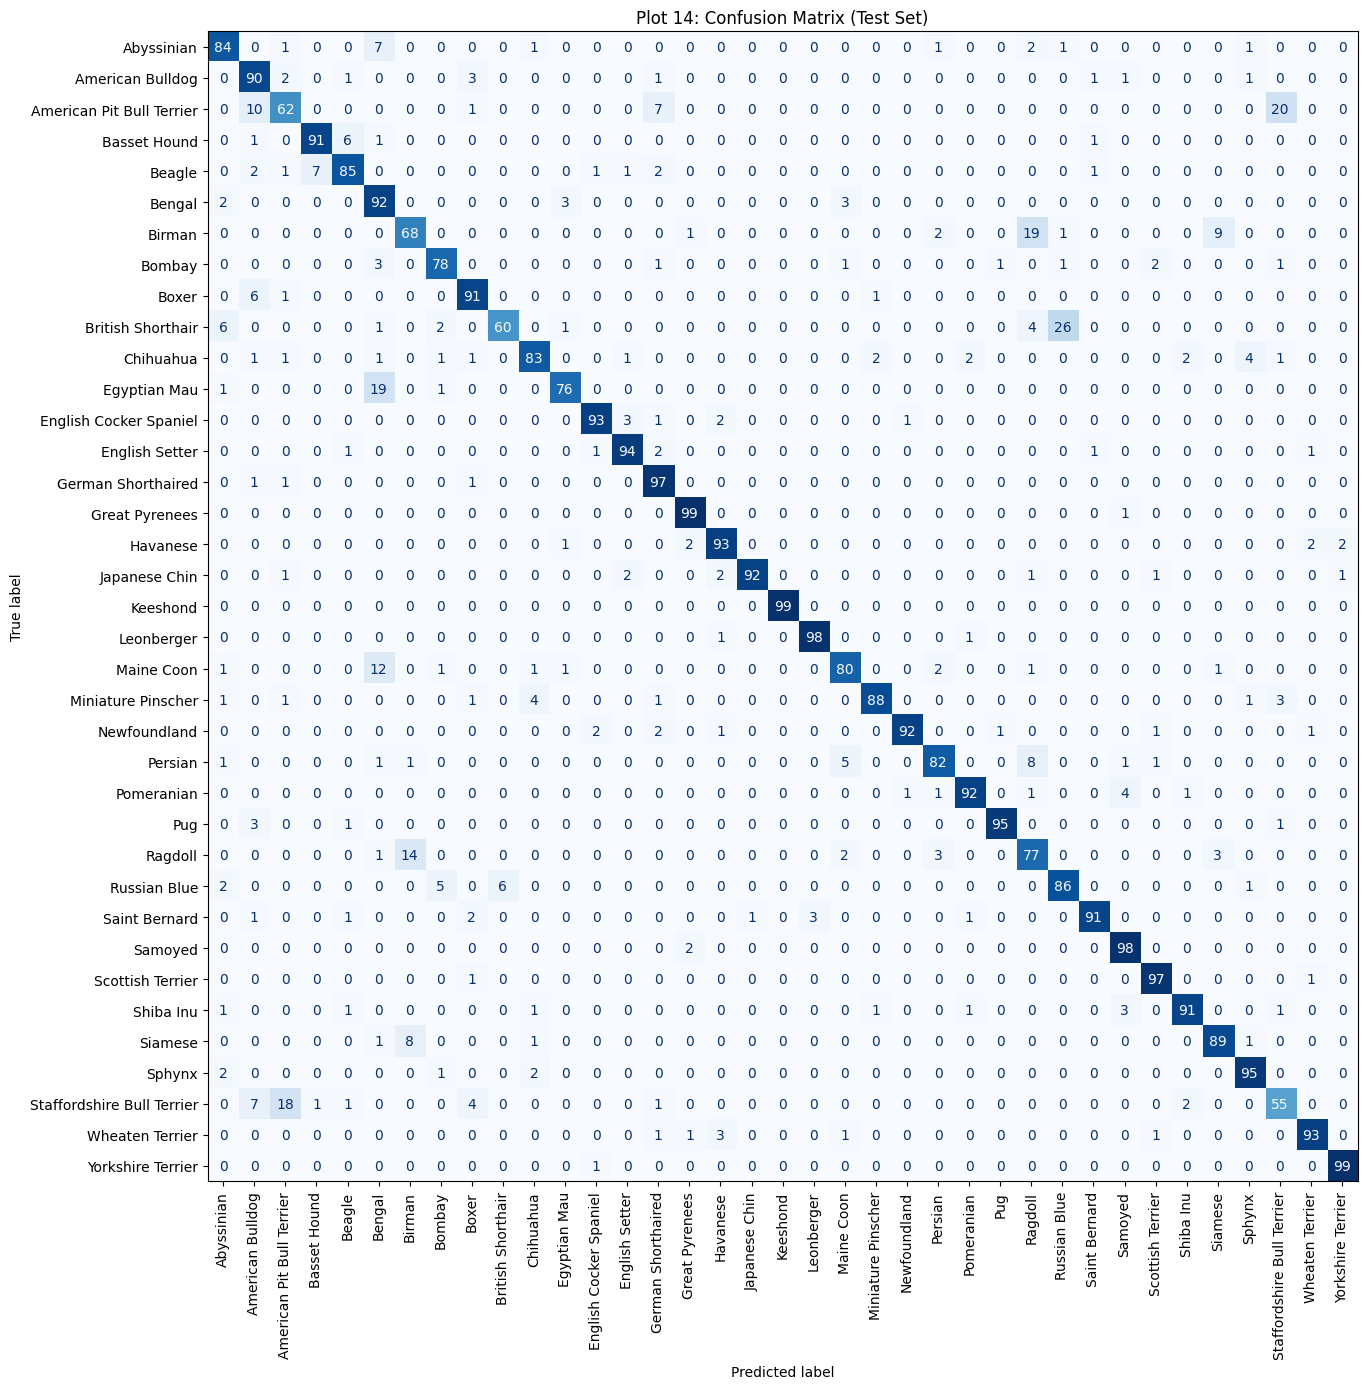

Best classified classes:
  Keeshond: 100.0%
  Great Pyrenees: 99.0%
  Yorkshire Terrier: 99.0%
  Samoyed: 98.0%
  Leonberger: 98.0%

Most frequently confused (lowest accuracy) classes:
  British Shorthair: 60.0%
  Staffordshire Bull Terrier: 61.8%
  American Pit Bull Terrier: 62.0%
  Birman: 68.0%
  Ragdoll: 77.0%


In [ ]:

# Plot 14: Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(14, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False, cmap="Blues")
plt.title("Plot 14: Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

# Identify best-classified and most-confused classes
per_class_acc = cm.diagonal() / cm.sum(axis=1)
best_classes = np.argsort(per_class_acc)[-5:][::-1]
worst_classes = np.argsort(per_class_acc)[:5]
print("Best classified classes:")
for i in best_classes:
    print(f"  {CLASS_NAMES[i]}: {per_class_acc[i]*100:.1f}%")
print("\nMost frequently confused (lowest accuracy) classes:")
for i in worst_classes:
    print(f"  {CLASS_NAMES[i]}: {per_class_acc[i]*100:.1f}%")


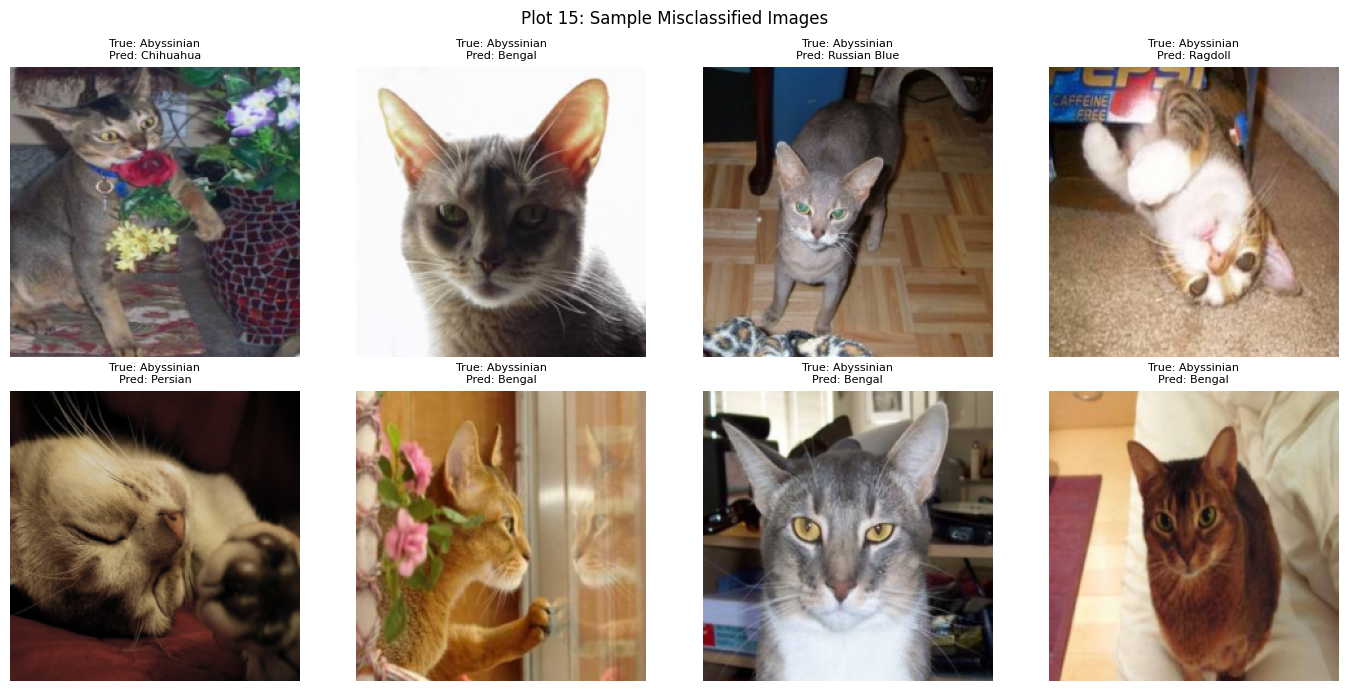

In [ ]:

# Optional Plot 15: Misclassified images
misclassified_idx = np.where(test_preds != test_labels)[0][:8]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for ax, idx in zip(axes.flatten(), misclassified_idx):
        img, true_label = test_set[idx]
        ax.imshow(denorm(img))
        ax.set_title(f"True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[test_preds[idx]]}", fontsize=8)
        ax.axis("off")
    plt.suptitle("Plot 15: Sample Misclassified Images")
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified samples found in the first batch scanned.")


## 11. Overall Results Summary (Section 13)
Consolidates the best result from each experiment stage into one comparison table.


In [ ]:

overall_rows = [
    {"Configuration": "Baseline (default init, Adam, no extra reg)",
     "CV Accuracy": "-", "SD": "-",
     "Test/Val Accuracy": round(max(init_histories["random"]["val_acc"]), 2),
     "Training Time (s)": "-"},
    {"Configuration": f"Best Initialization ({best_init})",
     "CV Accuracy": "-", "SD": "-",
     "Test/Val Accuracy": round(max(init_histories[best_init]["val_acc"]), 2),
     "Training Time (s)": "-"},
    {"Configuration": "Best Regularization",
     "CV Accuracy": "-", "SD": "-",
     "Test/Val Accuracy": round(max(max(h["val_acc"]) for h in reg_histories.values()), 2),
     "Training Time (s)": "-"},
    {"Configuration": f"Best Optimizer ({opt_df.sort_values('Best Val. Accuracy (%)', ascending=False).iloc[0]['Optimizer']})",
     "CV Accuracy": "-", "SD": "-",
     "Test/Val Accuracy": round(opt_df["Best Val. Accuracy (%)"].max(), 2),
     "Training Time (s)": round(opt_df.loc[opt_df["Best Val. Accuracy (%)"].idxmax(), "Time (s)"], 1)},
    {"Configuration": "Best Hyperparameters",
     "CV Accuracy": "-", "SD": "-",
     "Test/Val Accuracy": round(max(lr_results[best_lr], batch_results[best_batch], dropout_results[best_dropout]), 2),
     "Training Time (s)": "-"},
    {"Configuration": "Fine-Tuned Transfer Learning Model",
     "CV Accuracy": "-", "SD": "-",
     "Test/Val Accuracy": round(max(hist_ft["val_acc"]), 2),
     "Training Time (s)": round(time_ft, 1)},
    {"Configuration": f"FINAL MODEL ({best_config_name})",
     "CV Accuracy": round(np.mean(cv_results[best_config_name]), 2),
     "SD": round(np.std(cv_results[best_config_name]), 2),
     "Test/Val Accuracy": round(test_acc, 2),
     "Training Time (s)": round(final_train_time, 1)},
]
overall_df = pd.DataFrame(overall_rows)
overall_df


,Configuration,CV Accuracy,SD,Test/Val Accuracy,Training Time (s)
0,"Baseline (default init, Adam, no extra reg)",-,-,13.86,-
1,Best Initialization (xavier),-,-,14.40,-
2,Best Regularization,-,-,14.95,-
3,Best Optimizer (Adam),-,-,15.08,99.8
4,Best Hyperparameters,-,-,14.27,-
5,Fine-Tuned Transfer Learning Model,-,-,91.30,141.7
6,FINAL MODEL (C4_TransferLearning_FE),88.32,0.93,87.90,251.6


## 12. Additional Exercise (Section 16)
Evaluates **two new configurations** (different combos of LR / dropout / batch size / fine-tuning
strategy) with 5-fold CV, for comparison against the selected best configuration above.
Edit the two dicts below to try your own combinations.


In [ ]:

extra_configs = {
    "New_C5": dict(optimizer="Adam", lr=1e-4, dropout=0.5, pretrained=False),
    "New_C6": dict(optimizer="Adam", lr=1e-3, dropout=0.2, pretrained=True),  # feature-extraction style
}

extra_cv_results = {}
for name, cfg in extra_configs.items():
    print(f"\n=== Running 5-fold CV for {name} ===")
    fold_accs = run_kfold(cfg, k=5)
    extra_cv_results[name] = fold_accs
    print(f"{name}: mean={np.mean(fold_accs):.2f}  sd={np.std(fold_accs):.2f}")


In [ ]:

compare_rows = []
for name, accs in {**{best_config_name: cv_results[best_config_name]}, **extra_cv_results}.items():
    compare_rows.append({
        "Configuration": name,
        "Mean Accuracy": round(np.mean(accs), 2),
        "SD": round(np.std(accs), 2),
    })
compare_df = pd.DataFrame(compare_rows)
compare_df


**Interpretation guide for the report:** compare each new configuration to the originally
selected one on (1) mean accuracy, (2) standard deviation (lower = more consistent across folds),
and (3) approximate training time/compute cost. State explicitly whether the new configuration
is preferable and why — the highest single accuracy is *not* automatically the best model if it
comes with much higher variance or cost (see Discussion Question 23).


## 13. Discussion Questions (Section 15) — write-up checklist
Answer these in your LaTeX report using the results/plots generated above (not auto-generated
here, since they require your own written explanation):

1. Difference between model parameters and hyperparameters.
2. Why weight initialization matters.
3. Why zero initialization is problematic (symmetry — all neurons in a layer receive identical
   gradients and update identically).
4. Compare Xavier vs He initialization (Xavier assumes linear/tanh activations; He accounts for
   ReLU's zeroing of negative inputs, using a larger variance).
5–9. Use Plots 1–5 and the BN numerical example above.
10. Use Plots 6–7 and the optimizer table.
11–13. Use Plots 8–9 and your own reasoning about learning rate/batch size trade-offs.
14. Stride and padding — use the `O = floor((N + 2P - K)/S) + 1` formula from Section 9 of the
    handout.
15–19. Use the MobileNetV2 description (depthwise separable convolutions) and Section 8/10 results.
20–23. Use the K-Fold CV results (Section 9 of this notebook) and the Overall Results table.
